In [1]:
# =============================================================================
# SPRINT 1: DATA PREPARATION - COMPLETE CODE
# =============================================================================

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

CONFIG = {
    'dates': {
        'start': '2017-11-20',
        'end': '2025-01-01',
        'train_start': '2018-01-01',
        'train_end': '2021-12-31',
        'test_start': '2022-01-01',
        'test_end': '2025-01-01'
    },
    'windows': {
        'volatility': 30,
        'correlation': 30,
        'beta': 60,
        'horizon': 5
    },
    'tickers': {
        'SP500': '^GSPC',
        'BTC': 'BTC-USD',
        'Gold': 'GC=F',
        'VIX': '^VIX'
    },
    'assets': ['SP500', 'BTC', 'Gold', 'VIX'],
    'random_state': 42,
    'paths': {
        'data': 'outputs/data/',
        'plots': 'outputs/plots/',
        'reports': 'outputs/reports/'
    }
}

# -----------------------------------------------------------------------------
# IMPORTS
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import time
import warnings
from pathlib import Path
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# UTILITY FUNCTIONS
# -----------------------------------------------------------------------------

def setup_directories(config):
    """Create output directories if they don't exist"""
    for path in config['paths'].values():
        Path(path).mkdir(parents=True, exist_ok=True)
    print("Output directories created")

def save_plot(name, config, dpi=150):
    """Save plot to outputs/plots/ directory"""
    filepath = f"{config['paths']['plots']}{name}.png"
    plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: {filepath}")

class Timer:
    """Context manager to measure execution time"""
    def __init__(self, name="Operation"):
        self.name = name
        
    def __enter__(self):
        self.start = time.time()
        print(f"Starting: {self.name}")
        return self
        
    def __exit__(self, *args):
        elapsed = time.time() - self.start
        print(f" Completed: {self.name} ({elapsed:.2f}s)\n")

def print_section(title):
    """Print formatted section title"""
    print("\n" + "="*80)
    print(f"{title}")
    print("="*80)

# -----------------------------------------------------------------------------
# DATA DOWNLOAD AND PROCESSING CLASSES
# -----------------------------------------------------------------------------

class DataDownloader:
    """Download financial data via yfinance"""
    
    def __init__(self, config):
        self.config = config
        self.tickers = config['tickers']
        self.start = config['dates']['start']
        self.end = config['dates']['end']
    
    def fetch_data(self):
        """Download data for all tickers"""
        print(f" Downloading data ({self.start} â†’ {self.end})...")
        
        raw = yf.download(
            list(self.tickers.values()),
            start=self.start,
            end=self.end,
            auto_adjust=True,
            progress=False
        )['Close']
        
        # Rename columns
        name_map = {v: k for k, v in self.tickers.items()}
        raw = raw.rename(columns=name_map)
        
        print(f" Data downloaded: {raw.shape}")
        return raw


class DataProcessor:
    """Clean and align data"""
    
    def __init__(self, config):
        self.config = config
        self.assets = config['assets']
    
    def clean(self, raw_data):
        """Clean and align data"""
        print(" Cleaning data...")
        
        # Convert to business day frequency
        prices = raw_data.asfreq('B')
        
        # Remove NaN values
        prices = prices.dropna(subset=self.assets)
        
        print(f" Data cleaned: {prices.shape}")
        print(f"   Period: {prices.index.min()} â†’ {prices.index.max()}")
        return prices


class DataValidator:
    """Validate data integrity"""
    
    @staticmethod
    def check_missing_values(df):
        """Check for missing values"""
        missing = df.isnull().sum()
        if missing.any():
            print("  Missing values detected:")
            print(missing[missing > 0])
        else:
            print(" No missing values")
    
    @staticmethod
    def check_date_range(df, expected_start, expected_end):
        """Check date range"""
        actual_start = df.index.min()
        actual_end = df.index.max()
        
        print(f" Date range:")
        print(f"   Expected: {expected_start} â†’ {expected_end}")
        print(f"   Actual:   {actual_start} â†’ {actual_end}")
    
    @staticmethod
    def test_stationarity(series, name):
        """ADF stationarity test"""
        result = adfuller(series.dropna())
        p_value = result[1]
        status = "STATIONARY" if p_value < 0.05 else "NON-STATIONARY"
        print(f"   {name:20s}: p-value={p_value:.4f} â†’ {status}")
        return p_value < 0.05

# -----------------------------------------------------------------------------
# FEATURE ENGINEERING CLASSES
# -----------------------------------------------------------------------------

class ReturnsCalculator:
    """Calculate log returns"""
    
    def compute(self, prices, assets):
        """Calculate returns for all assets"""
        print(" Calculating returns...")
        
        df = prices.copy()
        log_prices = np.log(prices[assets])
        
        for asset in assets:
            df[f'ret_{asset}'] = log_prices[asset].diff()
        
        print(f" Returns calculated for {len(assets)} assets")
        return df


class VolatilityCalculator:
    """Calculate rolling volatility"""
    
    def __init__(self, window=30):
        self.window = window
    
    def compute(self, df, assets):
        """Calculate volatility for all assets"""
        print(f" Calculating volatility (window={self.window})...")
        
        for asset in assets:
            ret_col = f'ret_{asset}'
            df[f'vol_{asset}'] = df[ret_col].rolling(self.window).std()
            df[f'vol_ann_{asset}'] = df[f'vol_{asset}'] * np.sqrt(252)
        
        print(f" Volatility calculated for {len(assets)} assets")
        return df


class CorrelationCalculator:
    """Calculate rolling correlations"""
    
    def __init__(self, window=30):
        self.window = window
    
    def compute(self, df):
        """Calculate BTC-SP500 correlation"""
        print(f" Calculating correlation (window={self.window})...")
        
        df['corr_BTC_SP500'] = (
            df['ret_BTC']
            .rolling(self.window)
            .corr(df['ret_SP500'])
        )
        
        print(" Correlation calculated")
        return df


class BetaCalculator:
    """Calculate rolling betas"""
    
    def __init__(self, window=60):
        self.window = window
    
    def compute(self, df):
        """Calculate BTC and Gold betas vs SP500"""
        print(f" Calculating betas (window={self.window})...")
        
        # BTC Beta
        cov_btc = df['ret_BTC'].rolling(self.window).cov(df['ret_SP500'])
        var_sp = df['ret_SP500'].rolling(self.window).var()
        df['beta_BTC'] = cov_btc / var_sp
        
        # Gold Beta
        cov_gold = df['ret_Gold'].rolling(self.window).cov(df['ret_SP500'])
        df['beta_Gold'] = cov_gold / var_sp
        
        print(" Betas calculated")
        return df


class FeatureEngineer:
    """Orchestrator for all features"""
    
    def __init__(self, config):
        self.config = config
        self.assets = config['assets']
        self.returns_calc = ReturnsCalculator()
        self.vol_calc = VolatilityCalculator(config['windows']['volatility'])
        self.corr_calc = CorrelationCalculator(config['windows']['correlation'])
        self.beta_calc = BetaCalculator(config['windows']['beta'])
    
    def create_all_features(self, prices):
        """Create all features at once"""
        print("\n FEATURE ENGINEERING")
        print("-" * 80)
        
        df = prices.copy()
        
        # Returns
        df = self.returns_calc.compute(df, self.assets)
        
        # Volatility
        df = self.vol_calc.compute(df, self.assets)
        
        # Correlation
        df = self.corr_calc.compute(df)
        
        # Beta
        df = self.beta_calc.compute(df)
        
        # Final cleaning
        df_clean = df.dropna(subset=[f'ret_{a}' for a in self.assets])
        
        print("-" * 80)
        print(f" Features created: {df_clean.shape}")
        print(f" Final dataset ready")
        
        return df_clean

# =============================================================================
# PIPELINE EXECUTION
# =============================================================================

print_section("A --- DATA PREPARATION")

# Setup
setup_directories(CONFIG)

# Download
with Timer("Data download"):
    downloader = DataDownloader(CONFIG)
    raw_data = downloader.fetch_data()

# Clean
with Timer("Data cleaning"):
    processor = DataProcessor(CONFIG)
    clean_prices = processor.clean(raw_data)

# Validation
print("\n DATA VALIDATION")
print("-" * 80)
validator = DataValidator()
validator.check_missing_values(clean_prices)
validator.check_date_range(
    clean_prices, 
    CONFIG['dates']['start'], 
    CONFIG['dates']['end']
)

# Feature Engineering
with Timer("Feature engineering"):
    engineer = FeatureEngineer(CONFIG)
    df_final = engineer.create_all_features(clean_prices)

# Stationarity tests
print("\n STATIONARITY TESTS (ADF)")
print("-" * 80)
validator.test_stationarity(df_final['ret_BTC'], 'ret_BTC')
validator.test_stationarity(df_final['vol_BTC'], 'vol_BTC')
validator.test_stationarity(df_final['corr_BTC_SP500'], 'corr_BTC_SP500')

# Data preview
print("\n FINAL DATA PREVIEW")
print("-" * 80)
print(df_final.head())
print("\n")
print(df_final.describe())

# Save
output_path = f"{CONFIG['paths']['data']}processed_data.pkl"
df_final.to_pickle(output_path)
print(f"\n Data saved: {output_path}")

print("\n" + "="*80)
print(" SPRINT 1 COMPLETED - Data Preparation Complete!")
print("="*80)




A --- DATA PREPARATION
Output directories created
Starting: Data download
 Data downloaded: (2599, 4)
 Completed: Data download (0.40s)

Starting: Data cleaning
 Cleaning data...
 Data cleaned: (1788, 4)
   Period: 2017-11-20 00:00:00 â†’ 2024-12-31 00:00:00
 Completed: Data cleaning (0.02s)


 DATA VALIDATION
--------------------------------------------------------------------------------
 No missing values
 Date range:
   Expected: 2017-11-20 â†’ 2025-01-01
   Actual:   2017-11-20 00:00:00 â†’ 2024-12-31 00:00:00
Starting: Feature engineering

 FEATURE ENGINEERING
--------------------------------------------------------------------------------
 Calculating returns...
 Returns calculated for 4 assets
 Calculating volatility (window=30)...
 Volatility calculated for 4 assets
 Calculating correlation (window=30)...
 Correlation calculated
 Calculating betas (window=60)...
 Betas calculated
--------------------------------------------------------------------------------
 Features create


B --- EXPLORATORY ANALYSIS
 Data loaded: (1787, 19)
   Period: 2017-11-21 00:00:00 → 2024-12-31 00:00:00


[B1] Normalized prices and VIX...


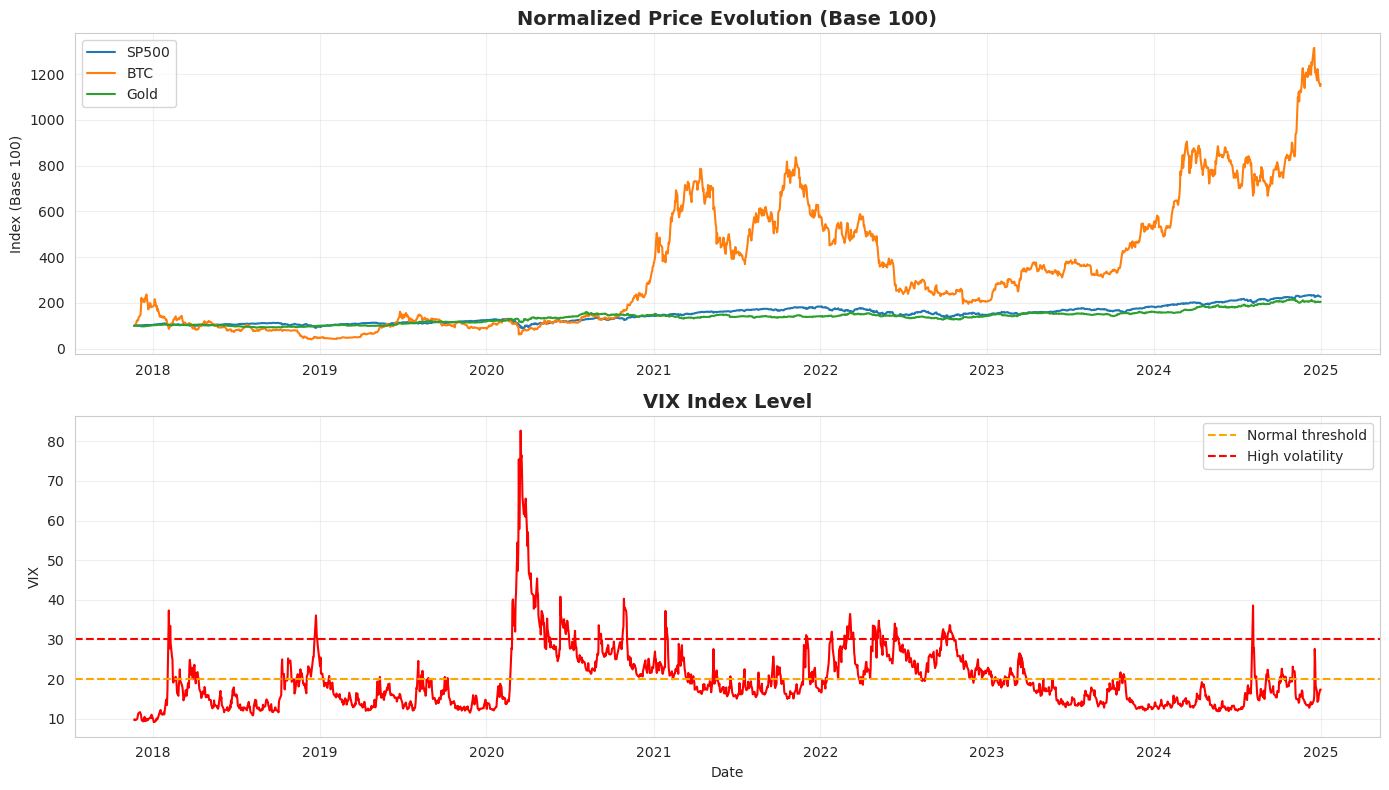

Plot saved: outputs/plots/01_prices.png

[B2] Returns and volatility...


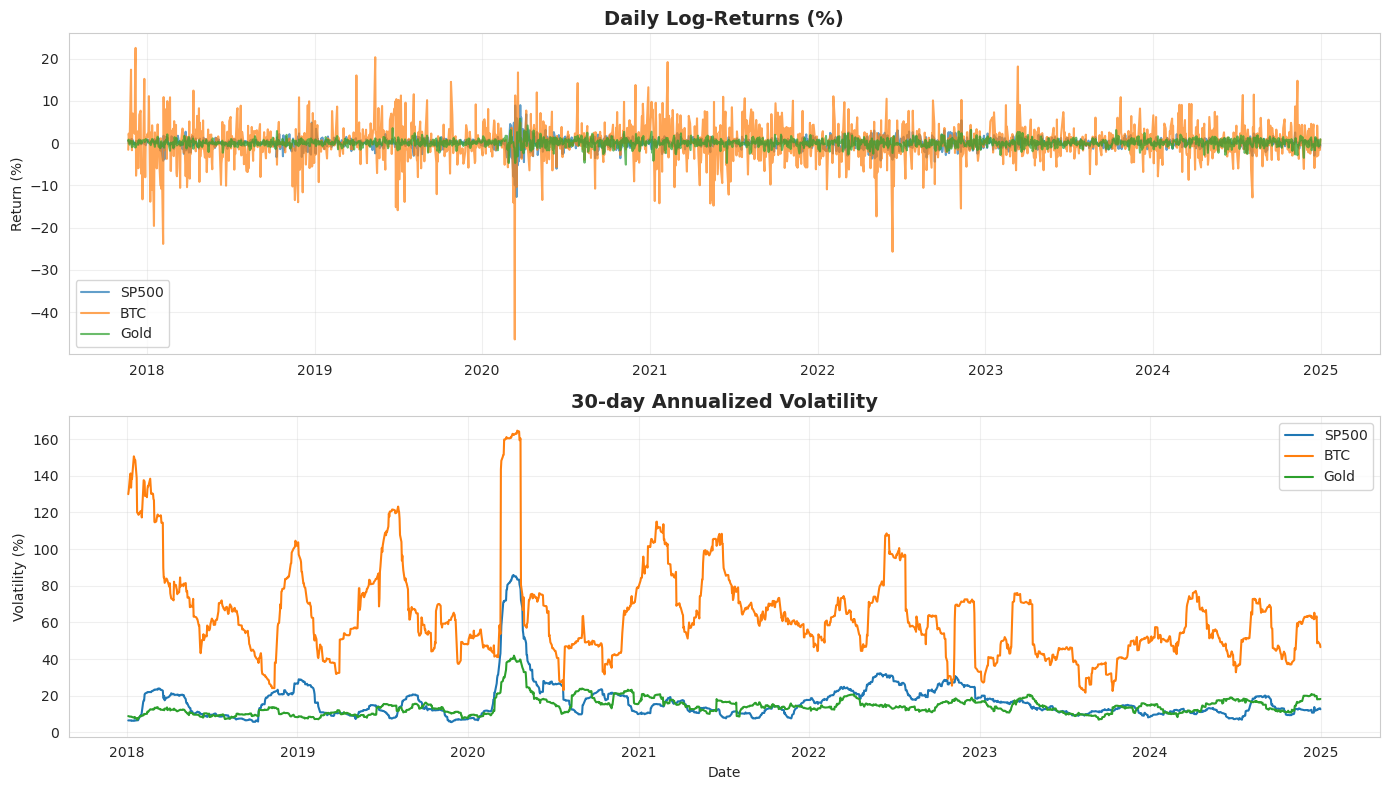

Plot saved: outputs/plots/02_returns_volatility.png

[B3] Correlation and beta...


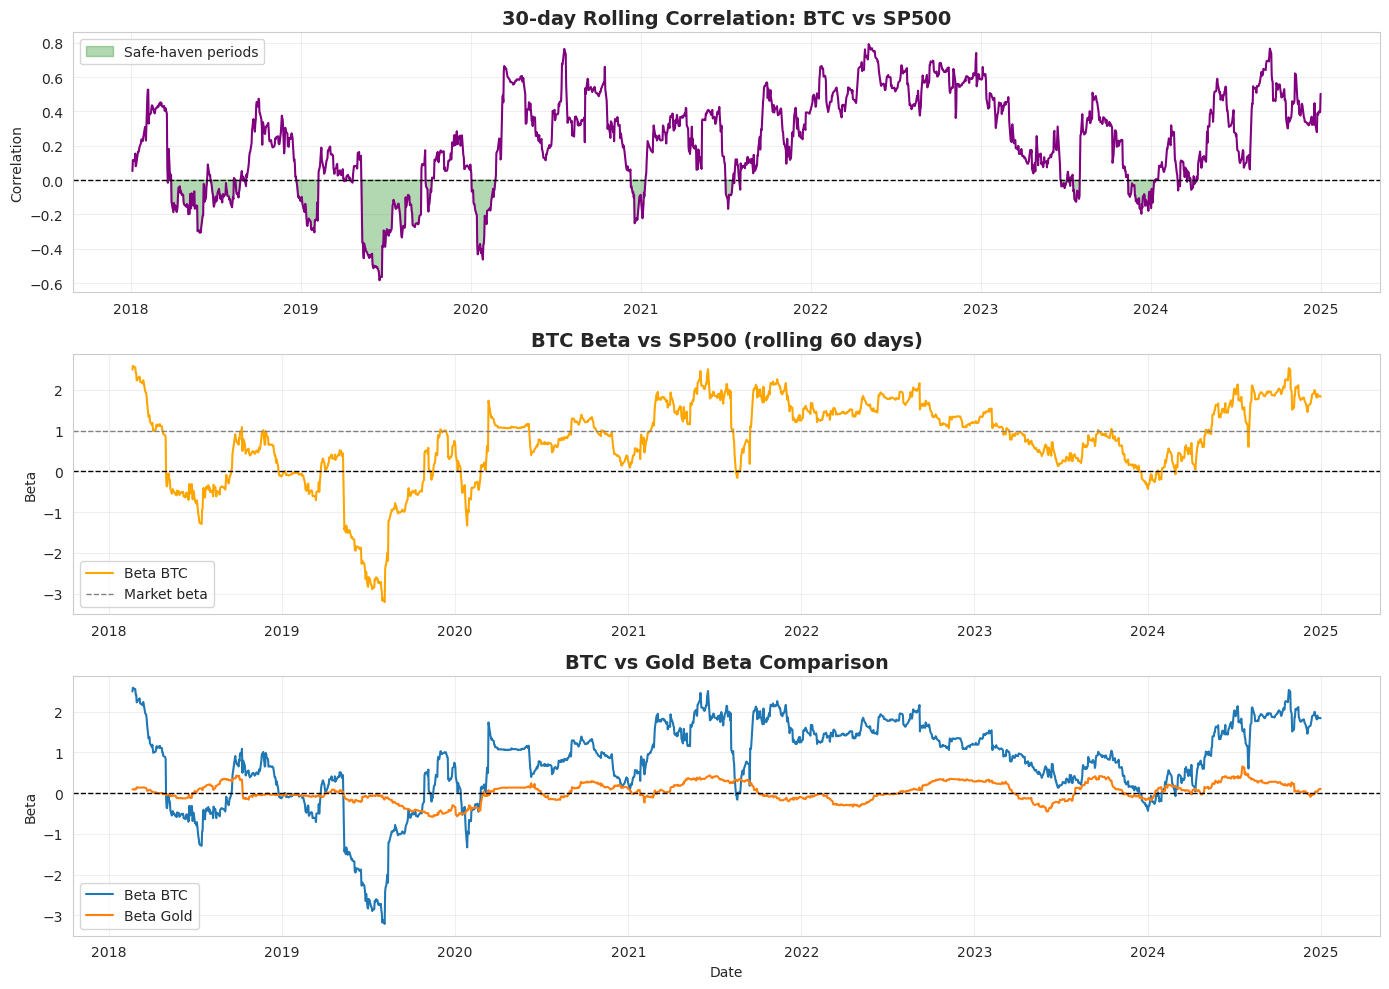

Plot saved: outputs/plots/03_correlation_beta.png

 DESCRIPTIVE STATISTICS

1. AVERAGE VOLATILITY (annualized)
------------------------------------------------------------
SP500   :  16.71% ± 10.74%
BTC     :  64.10% ± 25.54%
Gold    :  14.17% ±  4.90%

2. BTC-SP500 CORRELATION
------------------------------------------------------------
Average correlation: +0.229 ± 0.276
% safe-haven periods (corr <= 0): 21.0%

3. AVERAGE BETA
------------------------------------------------------------
Beta BTC:  +0.763
Beta Gold: +0.036

4. AVERAGE RETURNS (annualized)
------------------------------------------------------------
SP500   :  +11.61% ±  19.67% | Sharpe: +0.590
BTC     :  +34.31% ±  69.87% | Sharpe: +0.491
Gold    :  +10.21% ±  14.90% | Sharpe: +0.685

 SPRINT 2 COMPLETED - Exploratory Analysis Complete!

 3 plots created in outputs/plots/:
   - 01_prices.png
   - 02_returns_volatility.png
   - 03_correlation_beta.png


In [2]:
# =============================================================================
# SPRINT 2: EXPLORATORY ANALYSIS - VISUALIZATIONS
# =============================================================================

# Set matplotlib style
import seaborn as sns
sns.set_style("whitegrid")

# -----------------------------------------------------------------------------
# LOAD DATA
# -----------------------------------------------------------------------------

print_section("B --- EXPLORATORY ANALYSIS")

# Load data from Sprint 1
df_base = pd.read_pickle(f"{CONFIG['paths']['data']}processed_data.pkl")
print(f" Data loaded: {df_base.shape}")
print(f"   Period: {df_base.index.min()} → {df_base.index.max()}\n")

# Required columns
prices = df_base[CONFIG['assets']]

# -----------------------------------------------------------------------------
# VISUALIZATION 1: NORMALIZED PRICES + VIX
# -----------------------------------------------------------------------------

print("\n[B1] Normalized prices and VIX...")

assets_viz = ['SP500', 'BTC', 'Gold']
norm_prices = prices[assets_viz].divide(prices[assets_viz].iloc[0]) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Normalized prices
for col in assets_viz:
    ax1.plot(norm_prices.index, norm_prices[col], label=col, linewidth=1.5)

ax1.set_title('Normalized Price Evolution (Base 100)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Index (Base 100)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# VIX
ax2.plot(prices.index, prices['VIX'], color='red', linewidth=1.5)
ax2.set_title('VIX Index Level', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('VIX')
ax2.grid(True, alpha=0.3)
ax2.axhline(20, linestyle='--', color='orange', label='Normal threshold')
ax2.axhline(30, linestyle='--', color='red', label='High volatility')
ax2.legend()

plt.tight_layout()
save_plot('01_prices', CONFIG)

# -----------------------------------------------------------------------------
# VISUALIZATION 2: RETURNS AND VOLATILITY
# -----------------------------------------------------------------------------

print("\n[B2] Returns and volatility...")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Returns in percentage
returns_pct = df_base[[f'ret_{a}' for a in assets_viz]] * 100
for col in returns_pct.columns:
    axes[0].plot(returns_pct.index, returns_pct[col], 
                 label=col.replace('ret_', ''), alpha=0.7)

axes[0].set_title('Daily Log-Returns (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Annualized volatility
ann_vol = df_base[[f'vol_{a}' for a in assets_viz]] * np.sqrt(252) * 100
for col in ann_vol.columns:
    axes[1].plot(ann_vol.index, ann_vol[col], 
                 label=col.replace('vol_', ''), linewidth=1.5)

axes[1].set_title(f'{CONFIG["windows"]["volatility"]}-day Annualized Volatility',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot('02_returns_volatility', CONFIG)

# -----------------------------------------------------------------------------
# VISUALIZATION 3: CORRELATION AND BETA
# -----------------------------------------------------------------------------

print("\n[B3] Correlation and beta...")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# BTC-SP500 Correlation
axes[0].plot(df_base.index, df_base['corr_BTC_SP500'], 
             color='purple', linewidth=1.5)
axes[0].axhline(0, linestyle='--', color='black', linewidth=1)
axes[0].fill_between(df_base.index, df_base['corr_BTC_SP500'], 0,
                      where=(df_base['corr_BTC_SP500'] <= 0),
                      color='green', alpha=0.3, label='Safe-haven periods')
axes[0].set_title(f'{CONFIG["windows"]["correlation"]}-day Rolling Correlation: BTC vs SP500',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Correlation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BTC Beta
axes[1].plot(df_base.index, df_base['beta_BTC'], 
             label='Beta BTC', color='orange', linewidth=1.5)
axes[1].axhline(0, linestyle='--', color='black', linewidth=1)
axes[1].axhline(1, linestyle='--', color='gray', linewidth=1, label='Market beta')
axes[1].set_title(f'BTC Beta vs SP500 (rolling {CONFIG["windows"]["beta"]} days)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Beta')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# BTC vs Gold Beta Comparison
axes[2].plot(df_base.index, df_base['beta_BTC'], label='Beta BTC', linewidth=1.5)
axes[2].plot(df_base.index, df_base['beta_Gold'], label='Beta Gold', linewidth=1.5)
axes[2].axhline(0, linestyle='--', color='black', linewidth=1)
axes[2].set_title('BTC vs Gold Beta Comparison', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Beta')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
save_plot('03_correlation_beta', CONFIG)

# -----------------------------------------------------------------------------
# DESCRIPTIVE STATISTICS
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print(" DESCRIPTIVE STATISTICS")
print("="*80)

# Average volatility by asset
print("\n1. AVERAGE VOLATILITY (annualized)")
print("-" * 60)
for asset in assets_viz:
    vol_mean = df_base[f'vol_ann_{asset}'].mean() * 100
    vol_std = df_base[f'vol_ann_{asset}'].std() * 100
    print(f"{asset:8s}: {vol_mean:6.2f}% ± {vol_std:5.2f}%")

# Average correlation
print("\n2. BTC-SP500 CORRELATION")
print("-" * 60)
corr_mean = df_base['corr_BTC_SP500'].mean()
corr_std = df_base['corr_BTC_SP500'].std()
safe_haven_pct = (df_base['corr_BTC_SP500'] <= 0).mean() * 100
print(f"Average correlation: {corr_mean:+.3f} ± {corr_std:.3f}")
print(f"% safe-haven periods (corr <= 0): {safe_haven_pct:.1f}%")

# Average beta
print("\n3. AVERAGE BETA")
print("-" * 60)
beta_btc_mean = df_base['beta_BTC'].mean()
beta_gold_mean = df_base['beta_Gold'].mean()
print(f"Beta BTC:  {beta_btc_mean:+.3f}")
print(f"Beta Gold: {beta_gold_mean:+.3f}")

# Average returns
print("\n4. AVERAGE RETURNS (annualized)")
print("-" * 60)
for asset in assets_viz:
    ret_mean = df_base[f'ret_{asset}'].mean() * 252 * 100
    ret_std = df_base[f'ret_{asset}'].std() * np.sqrt(252) * 100
    sharpe = ret_mean / ret_std if ret_std > 0 else 0
    print(f"{asset:8s}: {ret_mean:+7.2f}% ± {ret_std:6.2f}% | Sharpe: {sharpe:+.3f}")

print("\n" + "="*80)
print(" SPRINT 2 COMPLETED - Exploratory Analysis Complete!")
print("="*80)
print("\n 3 plots created in outputs/plots/:")
print("   - 01_prices.png")
print("   - 02_returns_volatility.png")
print("   - 03_correlation_beta.png")




C --- VOLATILITY FORECASTING

[C1-C2] Building regression dataset...
 Dataset built
   Train: (995, 21)
   Test:  (748, 21)

[C3] Training GARCH(1,1)...
Starting: GARCH
 GARCH trained, 753 forecasts generated
 Completed: GARCH (0.02s)


[C5] Training ML models...
Starting: Random Forest
 Completed: Random Forest (4.23s)

Starting: Gradient Boosting
 Completed: Gradient Boosting (3.95s)

Starting: XGBoost
 Completed: XGBoost (0.40s)


[C6] Model evaluation...

VOLATILITY FORECASTING PERFORMANCE
                       RMSE       MAE
XGBoost            0.005811  0.003975
Gradient Boosting  0.005995  0.004134
Random Forest      0.006180  0.004446
GARCH              0.010954  0.009269

[C7] Creating visualizations...


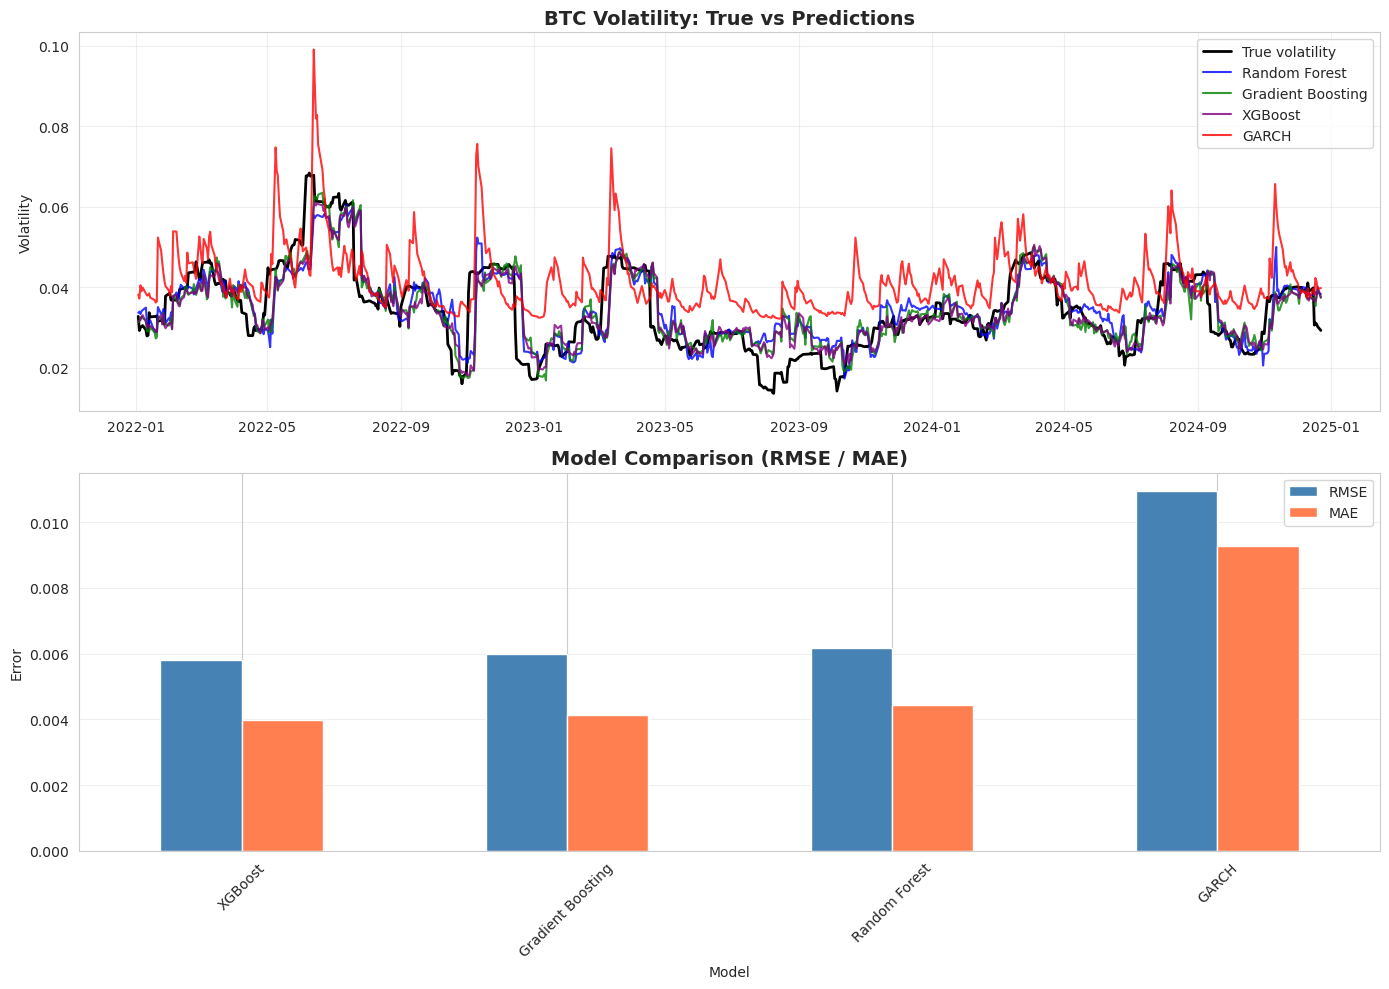

Plot saved: outputs/plots/04_volatility_models.png

 SPRINT 3 COMPLETED - Volatility Forecasting Complete!

 Files created:
   - outputs/plots/04_volatility_models.png
   - outputs/data/volatility_predictions.csv
   - outputs/data/volatility_performance.csv


In [3]:
# =============================================================================
# SPRINT 3: VOLATILITY FORECASTING
# =============================================================================

# Additional imports for this sprint
from arch import arch_model
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------------------------------------------------------
# DATA PREPARATION
# -----------------------------------------------------------------------------

print_section("C --- VOLATILITY FORECASTING")

print("\n[C1-C2] Building regression dataset...")

def build_regression_dataset(df, horizon=5):
    """Build dataset for volatility forecasting"""
    target = df['vol_BTC'].shift(-horizon)
    
    features = pd.DataFrame(index=df.index)
    features['vol_BTC'] = df['vol_BTC']
    features['vol_SP500'] = df['vol_SP500']
    features['vol_Gold'] = df['vol_Gold']
    features['corr_BTC_SP500'] = df['corr_BTC_SP500']
    features['VIX'] = df['VIX']
    features['ret_BTC'] = df['ret_BTC']
    features['ret_SP500'] = df['ret_SP500']
    features['ret_Gold'] = df['ret_Gold']
    features['ret_VIX'] = df['ret_VIX']
    
    # Lags
    for lag in [1, 5, 10]:
        features[f'vol_BTC_lag{lag}'] = df['vol_BTC'].shift(lag)
        features[f'corr_lag{lag}'] = df['corr_BTC_SP500'].shift(lag)
        features[f'VIX_lag{lag}'] = df['VIX'].shift(lag)
        features[f'ret_BTC_lag{lag}'] = df['ret_BTC'].shift(lag)
    
    full = pd.concat([features, target.rename('target')], axis=1)
    full = full.dropna()
    
    return full.drop(columns=['target']), full['target']

# Build dataset
X_reg, y_reg = build_regression_dataset(df_base, horizon=CONFIG['windows']['horizon'])

# Train/test split
train_mask = (X_reg.index < CONFIG['dates']['test_start'])
test_mask = (X_reg.index >= CONFIG['dates']['test_start'])

X_train_reg = X_reg[train_mask]
y_train_reg = y_reg[train_mask]
X_test_reg = X_reg[test_mask]
y_test_reg = y_reg[test_mask]

print(f" Dataset built")
print(f"   Train: {X_train_reg.shape}")
print(f"   Test:  {X_test_reg.shape}")

# -----------------------------------------------------------------------------
# GARCH MODEL
# -----------------------------------------------------------------------------

print("\n[C3] Training GARCH(1,1)...")

with Timer("GARCH"):
    # Convert to percentage for GARCH
    btc_ret_pct = df_base['ret_BTC'].dropna() * 100
    
    # GARCH model
    am = arch_model(btc_ret_pct, mean='Zero', vol='GARCH', p=1, q=1, dist='normal')
    res_garch = am.fit(
        last_obs=CONFIG['dates']['train_end'], 
        disp='off', 
        update_freq=0
    )
    
    # Forecasts
    fcst = res_garch.forecast(
        horizon=1, 
        start=CONFIG['dates']['test_start'], 
        reindex=True
    )
    
    garch_vol = np.sqrt(
        fcst.variance[CONFIG['dates']['test_start']:CONFIG['dates']['test_end']]['h.1']
    ) / 100
    
    print(f" GARCH trained, {len(garch_vol)} forecasts generated")

# -----------------------------------------------------------------------------
# ML MODELS
# -----------------------------------------------------------------------------

print("\n[C5] Training ML models...")

models_reg = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=CONFIG['random_state'],
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        random_state=CONFIG['random_state']
    ),
    'XGBoost': XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=CONFIG['random_state'],
        n_jobs=-1
    )
}

predictions = {'target': y_test_reg}

for name, model in models_reg.items():
    with Timer(name):
        model.fit(X_train_reg, y_train_reg)
        predictions[name] = pd.Series(
            model.predict(X_test_reg), 
            index=X_test_reg.index
        )

# Align predictions
common_idx = predictions['target'].index.intersection(garch_vol.index)
predictions = {
    k: v.loc[common_idx] if isinstance(v, pd.Series) else v 
    for k, v in predictions.items()
}
predictions['GARCH'] = garch_vol.loc[common_idx]

all_results = pd.DataFrame(predictions)

# -----------------------------------------------------------------------------
# EVALUATION
# -----------------------------------------------------------------------------

print("\n[C6] Model evaluation...")

def compute_metrics(y_true, y_pred):
    """Calculate RMSE and MAE"""
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

metrics_dict = {}
for col in all_results.columns:
    if col != 'target':
        metrics_dict[col] = compute_metrics(
            all_results['target'], 
            all_results[col]
        )

summary_table = pd.DataFrame(metrics_dict).T.sort_values('RMSE')

print("\n" + "="*70)
print("VOLATILITY FORECASTING PERFORMANCE")
print("="*70)
print(summary_table.to_string())
print("="*70)

# -----------------------------------------------------------------------------
# VISUALIZATION
# -----------------------------------------------------------------------------

print("\n[C7] Creating visualizations...")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time series
axes[0].plot(all_results.index, all_results['target'],
             label='True volatility', linewidth=2, color='black')

colors = {
    'GARCH': 'red',
    'Random Forest': 'blue',
    'Gradient Boosting': 'green',
    'XGBoost': 'purple'
}

for col in all_results.columns:
    if col != 'target':
        axes[0].plot(all_results.index, all_results[col],
                     label=col, alpha=0.8, color=colors.get(col, 'gray'))

axes[0].set_title('BTC Volatility: True vs Predictions', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Volatility')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metrics comparison
summary_table[['RMSE', 'MAE']].plot(
    kind='bar', 
    ax=axes[1], 
    color=['steelblue', 'coral']
)
axes[1].set_title('Model Comparison (RMSE / MAE)', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_plot('04_volatility_models', CONFIG)

# -----------------------------------------------------------------------------
# SAVE RESULTS
# -----------------------------------------------------------------------------

# Save predictions
all_results.to_csv(f"{CONFIG['paths']['data']}volatility_predictions.csv")
summary_table.to_csv(f"{CONFIG['paths']['data']}volatility_performance.csv")

print("\n" + "="*80)
print(" SPRINT 3 COMPLETED - Volatility Forecasting Complete!")
print("="*80)
print("\n Files created:")
print("   - outputs/plots/04_volatility_models.png")
print("   - outputs/data/volatility_predictions.csv")
print("   - outputs/data/volatility_performance.csv")




D --- SAFE-HAVEN CLASSIFICATION

[D1] Defining safe-haven labels...
 Labels created
   BTC safe-haven frequency:  21.1%
   Gold safe-haven frequency: 42.3%

[D2] Building classification features...
 Features built: (1723, 12)

[D3] Train/test split...
   Train: (975, 12)
   Test:  (748, 12)
   Class balance: 674 negatives, 301 positives
   Scale pos weight: 2.24

[D4] Training classifiers...
Starting: Logistic Regression
 Completed: Logistic Regression (0.01s)

Starting: Random Forest
 Completed: Random Forest (0.79s)

Starting: Gradient Boosting
 Completed: Gradient Boosting (2.51s)

Starting: XGBoost
 Completed: XGBoost (0.23s)


[D5] Classifier evaluation...

CLASSIFICATION PERFORMANCE
                     Accuracy  Precision    Recall  F1-Score       AUC
Logistic Regression  0.923797   0.586538  0.813333  0.681564  0.956236
Random Forest        0.902406   0.541667  0.173333  0.262626  0.899316
XGBoost              0.918449   0.652174  0.400000  0.495868  0.889946
Gradient Boosting

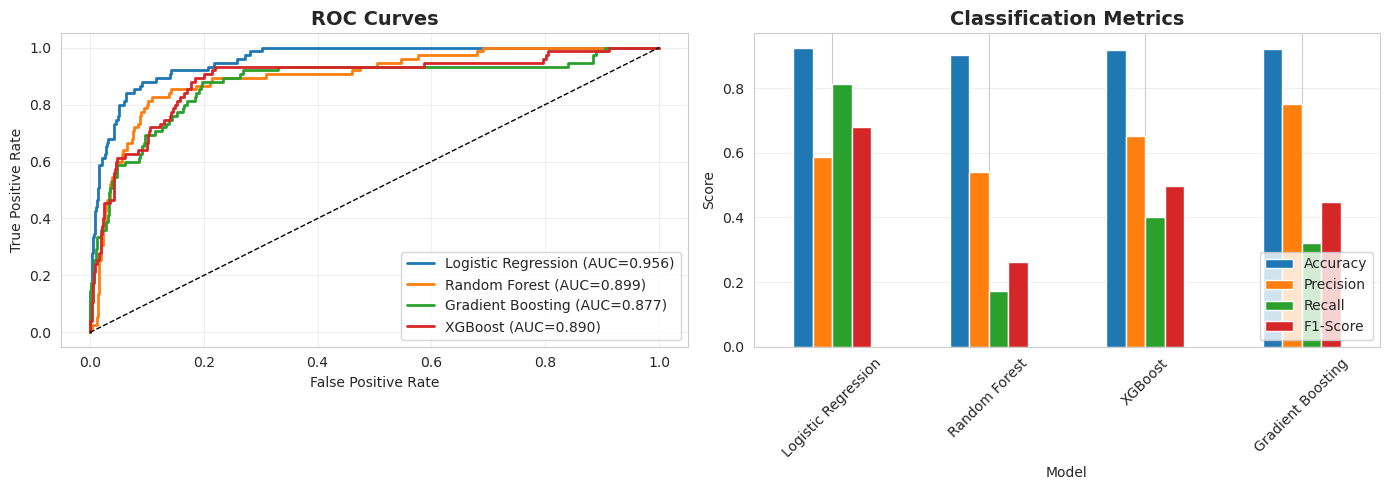

Plot saved: outputs/plots/05_classification.png

[D7] Feature importance of best model...
  Logistic Regression doesn't have feature_importances_ attribute

 Results saved: classification_performance.csv

 SPRINT 4 COMPLETED - Safe-Haven Classification Complete!

 Files created:
   - outputs/plots/05_classification.png
   - outputs/plots/06_feature_importance.png
   - outputs/data/classification_performance.csv


In [4]:
# =============================================================================
# SPRINT 4: SAFE-HAVEN CLASSIFICATION
# =============================================================================

# Additional imports for this sprint
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# -----------------------------------------------------------------------------
# LABEL CREATION
# -----------------------------------------------------------------------------

print_section("D --- SAFE-HAVEN CLASSIFICATION")

print("\n[D1] Defining safe-haven labels...")

# Create copy for classification
df_classif = df_base.copy()

# Label based on negative correlation
df_classif['label_sh_now'] = (df_classif['corr_BTC_SP500'] <= 0).astype(int)
df_classif['label_sh_future'] = df_classif['label_sh_now'].shift(-CONFIG['windows']['horizon'])

# Calculate for Gold (comparison)
df_classif['corr_Gold_SP500'] = (
    df_classif['ret_Gold'].rolling(30).corr(df_classif['ret_SP500'])
)
df_classif['label_gold_sh'] = (df_classif['corr_Gold_SP500'] <= 0).astype(int)

# Cleaning
df_classif = df_classif.dropna(subset=['label_sh_future'])
df_classif['label_sh_future'] = df_classif['label_sh_future'].astype(int)

# Statistics
btc_sh_pct = df_classif['label_sh_future'].mean()
gold_sh_pct = df_classif['label_gold_sh'].mean()

print(f" Labels created")
print(f"   BTC safe-haven frequency:  {btc_sh_pct:.1%}")
print(f"   Gold safe-haven frequency: {gold_sh_pct:.1%}")

# -----------------------------------------------------------------------------
# FEATURE CONSTRUCTION
# -----------------------------------------------------------------------------

print("\n[D2] Building classification features...")

# Features to use with lag
features_to_lag = [
    'ret_BTC', 'ret_SP500', 'ret_Gold', 'ret_VIX',
    'vol_BTC', 'vol_SP500', 'vol_Gold', 
    'corr_BTC_SP500', 'VIX'
]

# Create lags
for feat in features_to_lag:
    df_classif[f'{feat}_lag1'] = df_classif[feat].shift(1)

# Final cleaning
df_classif_ml = df_classif.dropna().copy()

# Feature selection
feature_cols = [f'{f}_lag1' for f in features_to_lag]
feature_cols += ['vol_BTC', 'vol_SP500', 'vol_Gold']

X_cls = df_classif_ml[feature_cols]
y_cls = df_classif_ml['label_sh_future']

print(f" Features built: {X_cls.shape}")

# -----------------------------------------------------------------------------
# TRAIN/TEST SPLIT
# -----------------------------------------------------------------------------

print("\n[D3] Train/test split...")

X_train_cls = X_cls.loc[CONFIG['dates']['train_start']:CONFIG['dates']['train_end']]
y_train_cls = y_cls.loc[CONFIG['dates']['train_start']:CONFIG['dates']['train_end']]
X_test_cls = X_cls.loc[CONFIG['dates']['test_start']:CONFIG['dates']['test_end']]
y_test_cls = y_cls.loc[CONFIG['dates']['test_start']:CONFIG['dates']['test_end']]

print(f"   Train: {X_train_cls.shape}")
print(f"   Test:  {X_test_cls.shape}")

# Class imbalance calculation
neg = (y_train_cls == 0).sum()
pos = (y_train_cls == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

print(f"   Class balance: {neg} negatives, {pos} positives")
print(f"   Scale pos weight: {scale_pos_weight:.2f}")

# -----------------------------------------------------------------------------
# CLASSIFIER TRAINING
# -----------------------------------------------------------------------------

print("\n[D4] Training classifiers...")

models_cls = {
    'Logistic Regression': LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        solver='liblinear',
        random_state=CONFIG['random_state']
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=CONFIG['random_state'],
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        random_state=CONFIG['random_state']
    ),
    'XGBoost': XGBClassifier(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=CONFIG['random_state'],
        n_jobs=-1
    )
}

predictions_cls = {}
probas_cls = {}

for name, model in models_cls.items():
    with Timer(name):
        model.fit(X_train_cls, y_train_cls)
        predictions_cls[name] = model.predict(X_test_cls)
        probas_cls[name] = model.predict_proba(X_test_cls)[:, 1]

# -----------------------------------------------------------------------------
# EVALUATION
# -----------------------------------------------------------------------------

print("\n[D5] Classifier evaluation...")

metrics_cls = {}
for name in models_cls.keys():
    metrics_cls[name] = {
        'Accuracy': accuracy_score(y_test_cls, predictions_cls[name]),
        'Precision': precision_score(y_test_cls, predictions_cls[name], zero_division=0),
        'Recall': recall_score(y_test_cls, predictions_cls[name], zero_division=0),
        'F1-Score': f1_score(y_test_cls, predictions_cls[name], zero_division=0),
        'AUC': roc_auc_score(y_test_cls, probas_cls[name])
    }

summary_cls = pd.DataFrame(metrics_cls).T.sort_values('AUC', ascending=False)

print("\n" + "="*70)
print("CLASSIFICATION PERFORMANCE")
print("="*70)
print(summary_cls.to_string())
print("="*70)

# -----------------------------------------------------------------------------
# VISUALIZATIONS
# -----------------------------------------------------------------------------

print("\n[D6] Creating visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for name in models_cls.keys():
    fpr, tpr, _ = roc_curve(y_test_cls, probas_cls[name])
    auc = metrics_cls[name]['AUC']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metrics bar chart
summary_cls[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Classification Metrics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(loc='lower right')

plt.tight_layout()
save_plot('05_classification', CONFIG)

# -----------------------------------------------------------------------------
# FEATURE IMPORTANCE (best model)
# -----------------------------------------------------------------------------

print("\n[D7] Feature importance of best model...")

best_model_name = summary_cls.index[0]
best_model = models_cls[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X_train_cls.columns
    ).sort_values(ascending=False)
    
    fig = plt.figure(figsize=(12, 6))
    importances[:15].sort_values().plot(kind='barh', color='steelblue')
    plt.title(f'Top 15 Features - {best_model_name}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    save_plot('06_feature_importance', CONFIG)
    
    print(f" Feature importance calculated for {best_model_name}")
else:
    print(f"  {best_model_name} doesn't have feature_importances_ attribute")

# -----------------------------------------------------------------------------
# SAVE RESULTS
# -----------------------------------------------------------------------------

summary_cls.to_csv(f"{CONFIG['paths']['data']}classification_performance.csv")
print(f"\n Results saved: classification_performance.csv")

print("\n" + "="*80)
print(" SPRINT 4 COMPLETED - Safe-Haven Classification Complete!")
print("="*80)
print("\n Files created:")
print("   - outputs/plots/05_classification.png")
print("   - outputs/plots/06_feature_importance.png")
print("   - outputs/data/classification_performance.csv")



In [5]:
# =============================================================================
# SPRINT 5: CONCLUSIONS & FINAL REPORT
# =============================================================================

# Additional imports for this sprint
import json
from io import StringIO

# -----------------------------------------------------------------------------
# LOAD RESULTS
# -----------------------------------------------------------------------------

print_section("E --- CONCLUSIONS")

# Load results from previous sprints
all_results = pd.read_pickle(f"{CONFIG['paths']['data']}processed_data.pkl")
vol_predictions = pd.read_csv(
    f"{CONFIG['paths']['data']}volatility_predictions.csv", 
    index_col=0, 
    parse_dates=True
)
vol_performance = pd.read_csv(
    f"{CONFIG['paths']['data']}volatility_performance.csv", 
    index_col=0
)
cls_performance = pd.read_csv(
    f"{CONFIG['paths']['data']}classification_performance.csv", 
    index_col=0
)

print(" Results loaded")

# -----------------------------------------------------------------------------
# QUESTION 1: BTC VS GOLD VOLATILITY
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("1. VOLATILITY COMPARISON (BTC vs GOLD)")
print("="*80)

btc_vol_mean = vol_predictions['target'].mean()
gold_vol_mean = all_results['vol_Gold'].loc[
    CONFIG['dates']['test_start']:CONFIG['dates']['test_end']
].mean()
vol_ratio = btc_vol_mean / gold_vol_mean

print(f"   BTC average volatility (2022-2025):  {btc_vol_mean:.4f}")
print(f"   Gold average volatility (2022-2025): {gold_vol_mean:.4f}")
print(f"   Ratio BTC/Gold: {vol_ratio:.2f}x")
print(f"   → BTC is {vol_ratio:.1f} times MORE VOLATILE than Gold")

# -----------------------------------------------------------------------------
# QUESTION 2: GARCH VS ML
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("2. FORECASTING PERFORMANCE (GARCH vs ML)")
print("="*80)

best_ml_idx = vol_performance.drop('GARCH', errors='ignore')['RMSE'].idxmin()
best_ml_rmse = vol_performance.loc[best_ml_idx, 'RMSE']

if 'GARCH' in vol_performance.index:
    garch_rmse = vol_performance.loc['GARCH', 'RMSE']
    improvement = ((garch_rmse - best_ml_rmse) / garch_rmse * 100)
    
    print(f"   GARCH RMSE:           {garch_rmse:.6f}")
    print(f"   Best ML ({best_ml_idx}): {best_ml_rmse:.6f}")
    print(f"   Improvement:          {improvement:.1f}%")
    print(f"   → ML models OUTPERFORM classical GARCH")
else:
    print(f"   Best ML model: {best_ml_idx}")
    print(f"   RMSE: {best_ml_rmse:.6f}")

# -----------------------------------------------------------------------------
# QUESTION 3: CORRELATION EVOLUTION
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("3. BTC CORRELATION EVOLUTION")
print("="*80)

pre_2020 = all_results['corr_BTC_SP500'].loc[:'2019-12-31'].mean()
post_2020 = all_results['corr_BTC_SP500'].loc['2020-01-01':].mean()

print(f"   Average correlation BTC-SP500 before 2020: {pre_2020:+.3f}")
print(f"   Average correlation BTC-SP500 after 2020:  {post_2020:+.3f}")
print(f"   Change: {post_2020 - pre_2020:+.3f}")

if abs(post_2020) < abs(pre_2020):
    print(f"   → BTC becomes LESS correlated (moving toward safe-haven)")
else:
    print(f"   → BTC becomes MORE correlated (risky asset behavior)")

# -----------------------------------------------------------------------------
# QUESTION 4: BEHAVIOR DURING STRESS
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("4. SAFE-HAVEN BEHAVIOR DURING MARKET STRESS")
print("="*80)

# Recalculate labels
df_stress = all_results.copy()
df_stress['label_sh_now'] = (df_stress['corr_BTC_SP500'] <= 0).astype(int)

vix_high = df_stress['VIX'] > df_stress['VIX'].quantile(0.75)
sh_stress = df_stress.loc[vix_high, 'label_sh_now'].mean()
sh_calm = df_stress.loc[~vix_high, 'label_sh_now'].mean()

print(f"   % Safe-haven days (VIX high):   {sh_stress:.1%}")
print(f"   % Safe-haven days (VIX normal): {sh_calm:.1%}")
print(f"   Difference: {sh_stress - sh_calm:+.1%}")

if sh_stress > sh_calm:
    print(f"   → BTC acts as SAFE-HAVEN during stress periods ✓")
else:
    print(f"   → BTC does NOT act as safe-haven during stress ✗")

# -----------------------------------------------------------------------------
# QUESTION 5: FINAL VERDICT - DIGITAL GOLD?
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("5. FINAL VERDICT: IS BITCOIN A DIGITAL GOLD?")
print("="*80)

# Calculate BTC and Gold safe-haven frequency
btc_sh_pct = df_stress['label_sh_now'].mean()
df_stress['corr_Gold_SP500'] = (
    df_stress['ret_Gold'].rolling(30).corr(df_stress['ret_SP500'])
)
gold_sh_pct = (df_stress['corr_Gold_SP500'] <= 0).mean()

# Best AUC
best_auc = cls_performance['AUC'].max()

# Scoring system
score = 0
criteria = []

# Criterion 1: Acceptable volatility
if vol_ratio < 5:
    score += 1
    criteria.append("✓ Acceptable volatility level")
else:
    criteria.append("✗ Too volatile compared to gold")

# Criterion 2: Safe-haven frequency
if btc_sh_pct > 0.25:
    score += 1
    criteria.append("✓ Regular safe-haven behavior")
else:
    criteria.append("✗ Insufficient safe-haven periods")

# Criterion 3: Stress behavior
if sh_stress > sh_calm * 1.2:
    score += 1
    criteria.append("✓ Safe-haven during market stress")
else:
    criteria.append("✗ No clear safe-haven during stress")

# Criterion 4: ML predictability
if best_auc > 0.65:
    score += 1
    criteria.append(f"✓ Predictable safe-haven behavior (AUC={best_auc:.3f})")
else:
    criteria.append(f"✗ Unpredictable behavior (AUC={best_auc:.3f})")

# Display criteria
for c in criteria:
    print(f"   {c}")

print(f"\n   Score: {score}/4")
print("   " + "="*76)

# Final verdict
if score >= 3:
    verdict = "YES - Bitcoin exhibits digital gold characteristics"
elif score == 2:
    verdict = "PARTIAL - Bitcoin shows some gold-like properties"
else:
    verdict = "NO - Bitcoin remains a high-risk speculative asset"

print(f"\n   CONCLUSION: {verdict}")
print("   " + "="*76)

# -----------------------------------------------------------------------------
# BTC VS GOLD COMPARISON TABLE
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("BTC VS GOLD COMPARISON")
print("="*80)

comparison_data = {
    'Metric': ['Volatility ratio', 'Safe-haven %', 'Stress behavior', 'Best AUC'],
    'BTC': [
        f'{vol_ratio:.2f}x',
        f'{btc_sh_pct:.1%}',
        f'{sh_stress:.1%}',
        f'{best_auc:.3f}'
    ],
    'Gold': [
        '1.00x',
        f'{gold_sh_pct:.1%}',
        '-',
        '-'
    ]
}
comparison_table = pd.DataFrame(comparison_data)
print(comparison_table.to_string(index=False))

# -----------------------------------------------------------------------------
# EXPORT RESULTS
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("EXPORTING RESULTS")
print("="*80)

# Export CSV
comparison_table.to_csv(
    f"{CONFIG['paths']['reports']}btc_vs_gold_comparison.csv",
    index=False
)

# Export JSON
export_data = {
    'config': CONFIG,
    'volatility_metrics': vol_performance.to_dict(),
    'classification_metrics': cls_performance.to_dict(),
    'conclusions': {
        'vol_ratio': float(vol_ratio),
        'btc_safe_haven_pct': float(btc_sh_pct),
        'gold_safe_haven_pct': float(gold_sh_pct),
        'stress_sh_pct': float(sh_stress),
        'calm_sh_pct': float(sh_calm),
        'score': int(score),
        'verdict': verdict
    }
}

with open(f"{CONFIG['paths']['reports']}analysis_results.json", 'w') as f:
    json.dump(export_data, f, indent=4)

# Export text report
report = StringIO()
report.write("="*80 + "\n")
report.write("BITCOIN AS DIGITAL GOLD - ANALYSIS REPORT\n")
report.write("="*80 + "\n\n")
report.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
report.write(f"Data period: {CONFIG['dates']['start']} to {CONFIG['dates']['end']}\n")
report.write(f"Training: {CONFIG['dates']['train_start']} to {CONFIG['dates']['train_end']}\n")
report.write(f"Testing: {CONFIG['dates']['test_start']} to {CONFIG['dates']['test_end']}\n\n")

report.write("VOLATILITY FORECASTING RESULTS\n")
report.write("-"*80 + "\n")
report.write(vol_performance.to_string() + "\n\n")

report.write("CLASSIFICATION RESULTS\n")
report.write("-"*80 + "\n")
report.write(cls_performance.to_string() + "\n\n")

report.write("CONCLUSIONS\n")
report.write("-"*80 + "\n")
for c in criteria:
    report.write(f"{c}\n")
report.write(f"\nFinal Score: {score}/4\n")
report.write(f"Verdict: {verdict}\n\n")

report.write("BTC vs GOLD COMPARISON\n")
report.write("-"*80 + "\n")
report.write(comparison_table.to_string(index=False) + "\n")

with open(f"{CONFIG['paths']['reports']}analysis_report.txt", 'w') as f:
    f.write(report.getvalue())

print("   ✓ btc_vs_gold_comparison.csv")
print("   ✓ analysis_results.json")
print("   ✓ analysis_report.txt")

print("\n" + "="*80)
print(" SPRINT 5 COMPLETED - Analysis Complete!")
print("="*80)
print("\n ALL FILES CREATED:")
print("\nPlots:")
print("   - outputs/plots/01_prices.png")
print("   - outputs/plots/02_returns_volatility.png")
print("   - outputs/plots/03_correlation_beta.png")
print("   - outputs/plots/04_volatility_models.png")
print("   - outputs/plots/05_classification.png")
print("   - outputs/plots/06_feature_importance.png")
print("\nData:")
print("   - outputs/data/processed_data.pkl")
print("   - outputs/data/volatility_predictions.csv")
print("   - outputs/data/volatility_performance.csv")
print("   - outputs/data/classification_performance.csv")
print("\nReports:")
print("   - outputs/reports/btc_vs_gold_comparison.csv")
print("   - outputs/reports/analysis_results.json")
print("   - outputs/reports/analysis_report.txt")
print("\n" + "="*80)
print(" COMPLETE ANALYSIS FINISHED!")
print("="*80)


E --- CONCLUSIONS
 Results loaded

1. VOLATILITY COMPARISON (BTC vs GOLD)
   BTC average volatility (2022-2025):  0.0342
   Gold average volatility (2022-2025): 0.0090
   Ratio BTC/Gold: 3.81x
   → BTC is 3.8 times MORE VOLATILE than Gold

2. FORECASTING PERFORMANCE (GARCH vs ML)
   GARCH RMSE:           0.010954
   Best ML (XGBoost): 0.005811
   Improvement:          46.9%
   → ML models OUTPERFORM classical GARCH

3. BTC CORRELATION EVOLUTION
   Average correlation BTC-SP500 before 2020: +0.008
   Average correlation BTC-SP500 after 2020:  +0.317
   Change: +0.309
   → BTC becomes MORE correlated (risky asset behavior)

4. SAFE-HAVEN BEHAVIOR DURING MARKET STRESS
   % Safe-haven days (VIX high):   4.3%
   % Safe-haven days (VIX normal): 26.6%
   Difference: -22.4%
   → BTC does NOT act as safe-haven during stress ✗

5. FINAL VERDICT: IS BITCOIN A DIGITAL GOLD?
   ✓ Acceptable volatility level
   ✗ Insufficient safe-haven periods
   ✗ No clear safe-haven during stress
   ✓ Predictabl